# Elife Paper 
## Figure 7: Lesion Experiment


In [117]:
import os 
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import json
import pickle
# import queue
from scipy.integrate import solve_ivp
from dual_pathway_model.functions import *
from dual_pathway_model.directory_functions import *
from dual_pathway_model.model import NN, Environment, params_base
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from pathlib import Path
import yaml
from dual_pathway_model.directory_functions import *
from dual_pathway_model.model import Environment, NN, params_base, build_and_run
from dual_pathway_model.plotting_functions import plot_colors, save_figure

In [118]:
save_figs = False

In [119]:
wanted_days = [0, 30, 60]
wanted_parameters = ["BG_INTACT_DAYS", "RA_INTACT_DAYS"]

In [120]:
HERE = Path.cwd()          # notebook directory
results_dir = HERE / "../Lesion_exp/results"

result_folders = find_subdirectories(results_dir, absolute=True)
selected_folders = []
for folder in result_folders:
    param_name = extract_param_name(folder)
    print(param_name)
    if param_name in wanted_parameters:
        selected_folders.append(folder)

print(selected_folders)

BG_INTACT_DAYS
RA_INTACT_DAYS
[WindowsPath('C:/Users/rsankar/Desktop/DualPathwayFigures/Repo20Feb2026/Dual_Pathway_RL_songbird/Lesion_exp/results/params_BG_INTACT_DAYS'), WindowsPath('C:/Users/rsankar/Desktop/DualPathwayFigures/Repo20Feb2026/Dual_Pathway_RL_songbird/Lesion_exp/results/params_RA_INTACT_DAYS')]


In [121]:
terminal_performance = {}
motor_variability = {}
meta = {}

for folder in selected_folders:
    param = extract_param_name(folder)

    perf_path = folder / "terminal_performance.npy"
    motor_var_path = folder / "terminal_motor_var.npy"
    meta_path = folder / "meta.yaml"

    if not perf_path.exists() or not meta_path.exists():
        print(f"⚠️ Skipping {folder.name} (missing files)")
        continue

    terminal_performance[param] = np.load(perf_path)
    motor_variability[param] = np.load(motor_var_path)

    with open(meta_path, "r") as f:
        meta[param] = yaml.safe_load(f)


In [122]:
print("Available days:", meta['BG_INTACT_DAYS']['values'])
print("Size of terminal performance data:", terminal_performance['BG_INTACT_DAYS'].shape)
print("Size of motor variability data:", motor_variability['BG_INTACT_DAYS'].shape)
print("Size of terminal performance data (RA):", terminal_performance['RA_INTACT_DAYS'].shape)
print("Size of motor variability data (RA):", motor_variability['RA_INTACT_DAYS'].shape)


# Data you already have
data = terminal_performance['BG_INTACT_DAYS']
data_ra = terminal_performance['RA_INTACT_DAYS']
data_motor_var = motor_variability['BG_INTACT_DAYS']
data_motor_var_ra = motor_variability['RA_INTACT_DAYS']
lesion_day_list = meta['BG_INTACT_DAYS']['values']
lesion_day_list_ra = meta['RA_INTACT_DAYS']['values']
print("Wanted days:", wanted_days)
conditions = ['Before Lesion', 'After Lesion', 'Terminal Performance']

Available days: [0.0, 1.0, 5.0, 30.0, 60.0]
Size of terminal performance data: (100, 5, 3)
Size of motor variability data: (100, 5, 3)
Size of terminal performance data (RA): (100, 5, 3)
Size of motor variability data (RA): (100, 5, 3)
Wanted days: [0, 30, 60]


In [123]:
def plot_results_violin_conditions(
    data,
    lesion_day_list,
    wanted_days,
    conditions,
    plot_colors=plot_colors,
    success_threshold=0.7,
    figsize=(12, 5),
    print_success_rate=True,
    lesion="BG",
    print_stats=False
):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    wanted_indices = [lesion_day_list.index(day) for day in wanted_days]
    n_conditions = len(conditions)
    if lesion == "BG":
        colors = ['grey', 'lightsteelblue', 'steelblue']
    if lesion == "RA":
        colors = ['grey', 'goldenrod', 'darkgoldenrod']

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = fig.add_gridspec(
        2, len(wanted_days),
        height_ratios=[4, 10],
        hspace=0.05,
        wspace=0.15
    )

    shared_ax = None

    for col, (day_idx, day) in enumerate(zip(wanted_indices, wanted_days)):
        ax_bar = fig.add_subplot(gs[0, col])
        ax = fig.add_subplot(gs[1, col], sharey=shared_ax)
        if shared_ax is None:
            shared_ax = ax

        swap_indices = [0, 1, 2]
        metric_data = data[:, day_idx, swap_indices]

        success_rate = np.mean(metric_data > success_threshold, axis=0) * 100
        xpos = np.arange(n_conditions)

        ax_bar.bar(xpos, success_rate, color=colors, alpha=0.75, width=0.4)

        if print_success_rate:
            for i, val in enumerate(success_rate):
                ax_bar.text(i, val + 3, int(val), ha='center', va='bottom', fontsize=20)

        ax_bar.set_ylim(0, 100)
        ax_bar.set_yticks([0, 100])
        ax_bar.tick_params(axis='x', bottom=False, labelbottom=False)
        ax_bar.spines['top'].set_visible(False)
        ax_bar.spines['bottom'].set_visible(False)

        if col == 0:
            ax_bar.spines['right'].set_visible(False)
            ax_bar.spines['left'].set_bounds(0, 100)
            ax_bar.yaxis.tick_left()
            ax_bar.set_ylabel('Success\nrate (%)', fontsize=20, rotation=90, labelpad=-25)
            ax_bar.tick_params(axis='y', labelsize=20)
        else:
            ax_bar.spines['left'].set_visible(False)
            ax_bar.spines['right'].set_visible(False)
            ax_bar.set_yticklabels([])
            ax_bar.tick_params(axis='y', length=0)

        plot_data = []
        plot_labels = []
        for j, cond in enumerate(conditions):
            plot_data.append(metric_data[:, j])
            plot_labels.extend([cond] * metric_data.shape[0])
        plot_data = np.concatenate(plot_data)

        ax.axhspan(success_threshold, 1.2, alpha=0.25, color="grey")

        palette = {
            'Before Lesion': colors[0],
            'After Lesion': colors[1],
            'Terminal Performance': colors[2]
        }

        sns.violinplot(
            x=plot_labels, y=plot_data, inner=None, palette=palette,
            linewidth=0, cut=0, bw_adjust=0.5, width=1, ax=ax
        )

        for c in ax.collections:
            if hasattr(c, "get_paths"):
                for path in c.get_paths():
                    verts = path.vertices
                    x_center = np.median(verts[:, 0])
                    verts[:, 0] = np.maximum(verts[:, 0], x_center)

        strip = sns.stripplot(
            x=plot_labels, y=plot_data, size=3,
            color=plot_colors['violin_plot_colors']['color_strip'],
            alpha=0.9, jitter=0.1, ax=ax
        )

        for coll in strip.collections:
            offsets = coll.get_offsets()
            offsets[:, 0] -= 0.2
            coll.set_offsets(offsets)

        ax.axhline(success_threshold, 0.02, .98, color='dimgray', linestyle='--', linewidth=2)

        k = int(day + 40)
        ax.set_ylim(0, 1.015)

        if col == 0:
            ax.set_yticks([0, success_threshold, 1])
            ax.set_yticklabels(['0', '.7', '1'], fontsize=20)
        else:
            ax.tick_params(axis='y', left=False, labelleft=False)

        ax.set_xlim(-0.45, n_conditions - 0.4)
        ax.set_xticks(np.arange(n_conditions) - 0.05)
        ax.set_xticklabels([f'{k - 1}', f'{k}', '102'], rotation=0, ha='center', fontsize=20)
        ax.tick_params(axis='x', which='major', length=0, labelsize=20)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if col == 0:
            ax.spines['left'].set_bounds(0, 1)
            ax.set_ylabel("Terminal\nperformance", fontsize=20, labelpad=0)
            ax.yaxis.set_label_coords(-0.12, 0.42)
        else:
            ax.spines['left'].set_visible(False)
            ax.set_ylabel("")

        trans = ax.get_xaxis_transform()
        x_break = 1.5
        dx, dy = 0.015, 0.01
        for xb in [x_break - 0.015, x_break + 0.015]:
            ax.plot([xb - dx, xb + dx], [-dy, dy], transform=trans, color='k', lw=1, clip_on=False)

        # ax.set_xlabel(f"Lesion before dph {k}", fontsize=12, labelpad=12)

        if print_stats:
            medians = np.median(metric_data, axis=0)
            iqr = [np.percentile(metric_data, 75, axis=0), np.percentile(metric_data, 25, axis=0)]
            print(f"\nStats for lesion at day {day} ({lesion}):")
            for i, median in enumerate(medians):
                print(f"Median for {conditions[i]}: {median*100:.2f} [{iqr[1][i]*100:.2f} - {iqr[0][i]*100:.2f}]")

    return fig



Stats for lesion at day 0 (BG):
Median for Before Lesion: nan [nan - nan]
Median for After Lesion: 39.63 [27.80 - 47.09]
Median for Terminal Performance: 37.82 [28.13 - 47.94]

Stats for lesion at day 30 (BG):
Median for Before Lesion: 92.40 [89.11 - 94.63]
Median for After Lesion: 95.63 [86.33 - 97.71]
Median for Terminal Performance: 93.72 [82.70 - 97.75]


C:\Users\rsankar\AppData\Local\Temp\ipykernel_7196\3854169436.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\rsankar\AppData\Local\Temp\ipykernel_7196\3854169436.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\rsankar\AppData\Local\Temp\ipykernel_7196\3854169436.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(



Stats for lesion at day 60 (BG):
Median for Before Lesion: 98.15 [96.68 - 98.83]
Median for After Lesion: 98.12 [95.87 - 99.07]
Median for Terminal Performance: 98.14 [96.02 - 99.08]


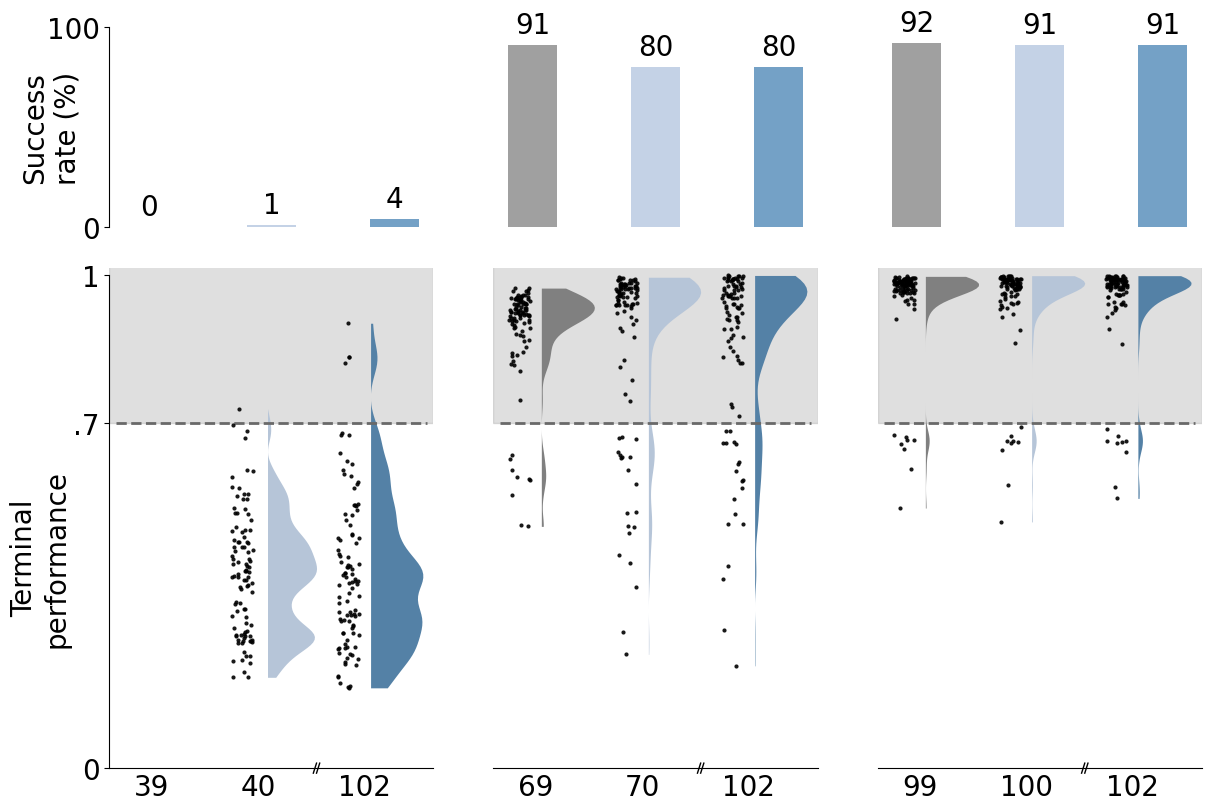

In [124]:

# Call the style-consistent plotting function
fig = plot_results_violin_conditions(
    data=data,
    lesion_day_list=lesion_day_list,
    wanted_days=wanted_days,
    conditions=conditions,
    plot_colors=plot_colors,
    success_threshold=0.7,
    figsize=(12, 8),
    print_stats = True,
)

save_figure("Figure_7b_v2", save=save_figs)

C:\Users\rsankar\AppData\Local\Temp\ipykernel_7196\3854169436.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\rsankar\AppData\Local\Temp\ipykernel_7196\3854169436.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\rsankar\AppData\Local\Temp\ipykernel_7196\3854169436.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(



Stats for lesion at day 0 (RA):
Median for Before Lesion: nan [nan - nan]
Median for After Lesion: 12.97 [4.37 - 27.73]
Median for Terminal Performance: 71.17 [59.64 - 77.56]

Stats for lesion at day 30 (RA):
Median for Before Lesion: 92.40 [89.11 - 94.63]
Median for After Lesion: 28.68 [14.32 - 39.21]
Median for Terminal Performance: 69.75 [51.59 - 75.70]

Stats for lesion at day 60 (RA):
Median for Before Lesion: 98.15 [96.68 - 98.83]
Median for After Lesion: 24.41 [15.26 - 31.80]
Median for Terminal Performance: 52.48 [47.15 - 61.20]


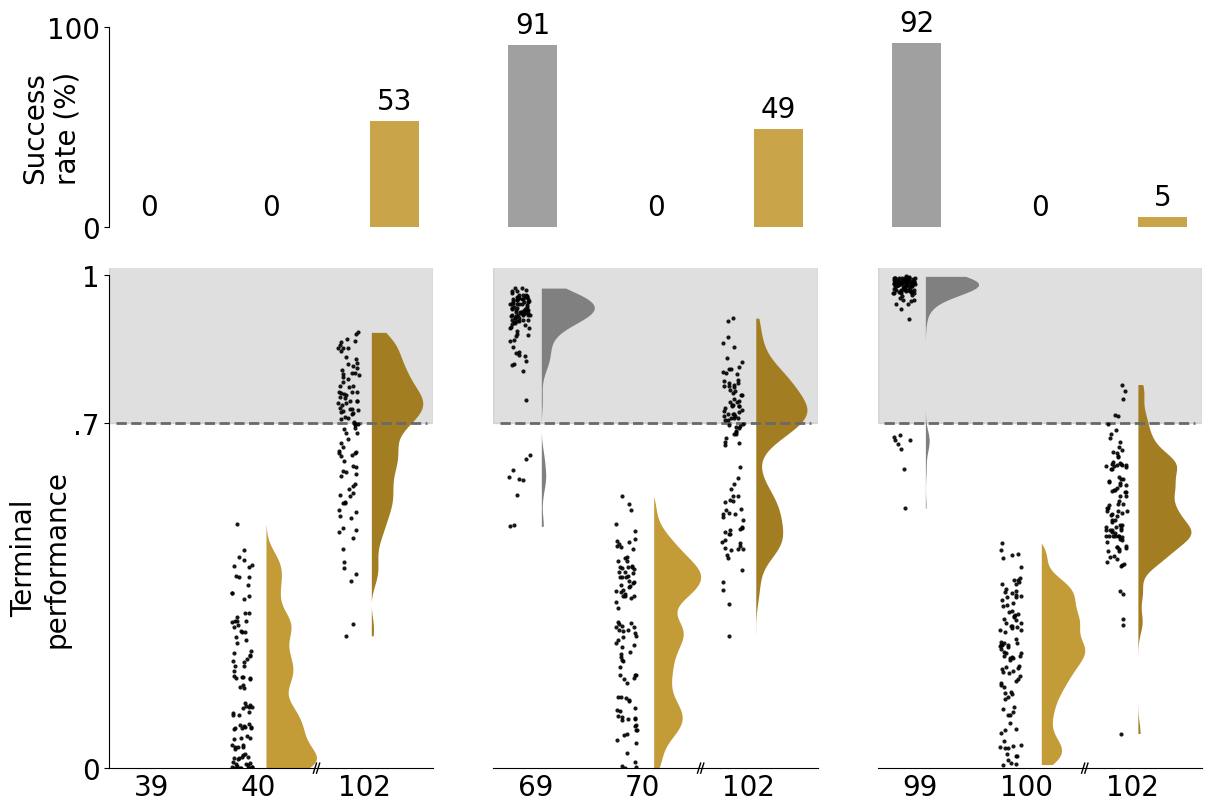

In [125]:

# Call the style-consistent plotting function
fig = plot_results_violin_conditions(
    data=data_ra,
    lesion_day_list=lesion_day_list,
    wanted_days=wanted_days,
    conditions=conditions,
    plot_colors=plot_colors,
    success_threshold=0.7,
    figsize=(12, 8),
    lesion="RA",
    print_stats = True,
)

save_figure("Figure_7e_v2", save=save_figs)

In [126]:
def plot_motor_var_violin_conditions(
    data,
    lesion_day_list,
    wanted_days,
    conditions,
    plot_colors=plot_colors,
    figsize=(12, 5),
    lesion="BG",
    print_stats=False
):
    wanted_indices = [lesion_day_list.index(day) for day in wanted_days]
    n_conditions = len(conditions)
    if lesion == "BG":
        colors = ['grey', 'lightsteelblue', 'steelblue']
    if lesion == "RA":
        colors = ['grey', 'goldenrod', 'darkgoldenrod']

    swap_indices = [0, 1, 2]
    reordered_conditions = [conditions[i] for i in swap_indices]
    palette = {
        reordered_conditions[0]: colors[0],
        reordered_conditions[1]: colors[1],
        reordered_conditions[2]: colors[2],
    }

    y_lower, y_upper = 0.0, 1.0

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = fig.add_gridspec(1, len(wanted_days), hspace=0.05, wspace=0.15)

    shared_ax = None

    for col, (day_idx, day) in enumerate(zip(wanted_indices, wanted_days)):
        ax = fig.add_subplot(gs[0, col], sharey=shared_ax)
        if shared_ax is None:
            shared_ax = ax

        metric_data = data[:, day_idx, swap_indices]

        plot_data = []
        plot_labels = []
        for j, cond in enumerate(reordered_conditions):
            plot_data.append(metric_data[:, j])
            plot_labels.extend([cond] * len(metric_data[:, j]))
        plot_data = np.concatenate(plot_data)

        sns.violinplot(
            x=plot_labels, y=plot_data, order=reordered_conditions,
            inner=None, palette=palette, linewidth=0, cut=0,
            bw_adjust=0.5, width=1, ax=ax,
        )

        for collection in ax.collections:
            if hasattr(collection, "get_paths"):
                for path in collection.get_paths():
                    verts = path.vertices
                    x_center = np.median(verts[:, 0])
                    verts[:, 0] = np.maximum(verts[:, 0], x_center)

        strip = sns.stripplot(
            x=plot_labels, y=plot_data, order=reordered_conditions,
            size=3, color=plot_colors["violin_plot_colors"]["color_strip"],
            alpha=0.9, jitter=0.1, ax=ax,
        )

        for coll in strip.collections:
            offsets = coll.get_offsets()
            if len(offsets):
                offsets[:, 0] -= 0.2
                coll.set_offsets(offsets)

        k = int(day + 40)
        ax.set_ylim(y_lower, y_upper)

        if col == 0:
            ax.set_yticks([y_lower, y_upper])
            ax.tick_params(axis='y', labelsize=20)
        else:
            ax.tick_params(axis="y", left=False, labelleft=False)

        ax.set_xlim(-0.45, n_conditions - 0.4)
        ax.set_xticks(np.arange(n_conditions) - 0.05)
        ax.set_xticklabels([f"{k - 1}", f"{k}", "102"], rotation=0, ha="center", fontsize=20)
        ax.tick_params(axis="x", which="major", length=0, labelsize=20)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if col == 0:
            ax.spines["left"].set_bounds(y_lower, y_upper)
            ax.set_ylabel("Motor\nvariability", fontsize=20, labelpad=-5)
        else:
            ax.spines["left"].set_visible(False)
            ax.set_ylabel("")

        trans = ax.get_xaxis_transform()
        x_break = 1.5
        dx, dy = 0.015, 0.01
        for xb in [x_break - 0.015, x_break + 0.015]:
            ax.plot([xb - dx, xb + dx], [-dy, dy], transform=trans, color="k", lw=1, clip_on=False)

        if col == 1:
            ax.set_xlabel("DPH", fontsize=25, labelpad=5)

        ax.set_title(f"Lesion before\ndph {k}", fontsize=30, y=-0.28, va="top")

        if print_stats:
            print(f"\nStats for lesion at day {day} ({lesion}):")
            medians = np.median(metric_data, axis=0)
            iqr = [np.percentile(metric_data, 75, axis=0), np.percentile(metric_data, 25, axis=0)]
            for i, median in enumerate(medians):
                print(f"Median for {conditions[i]}: {median:.4f} [{iqr[1][i]:.4f} - {iqr[0][i]:.4f}]")

    return fig


C:\Users\rsankar\AppData\Local\Temp\ipykernel_7196\3677156679.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\rsankar\AppData\Local\Temp\ipykernel_7196\3677156679.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\rsankar\AppData\Local\Temp\ipykernel_7196\3677156679.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(



Stats for lesion at day 0 (BG):
Median for Before Lesion: nan [nan - nan]
Median for After Lesion: 0.1457 [0.1440 - 0.1481]
Median for Terminal Performance: 0.0528 [0.0477 - 0.0588]

Stats for lesion at day 30 (BG):
Median for Before Lesion: 0.1119 [0.0913 - 0.1464]
Median for After Lesion: 0.0341 [0.0254 - 0.0433]
Median for Terminal Performance: 0.0009 [0.0003 - 0.0039]

Stats for lesion at day 60 (BG):
Median for Before Lesion: 0.0384 [0.0259 - 0.0546]
Median for After Lesion: 0.0072 [0.0028 - 0.0128]
Median for Terminal Performance: 0.0065 [0.0023 - 0.0120]


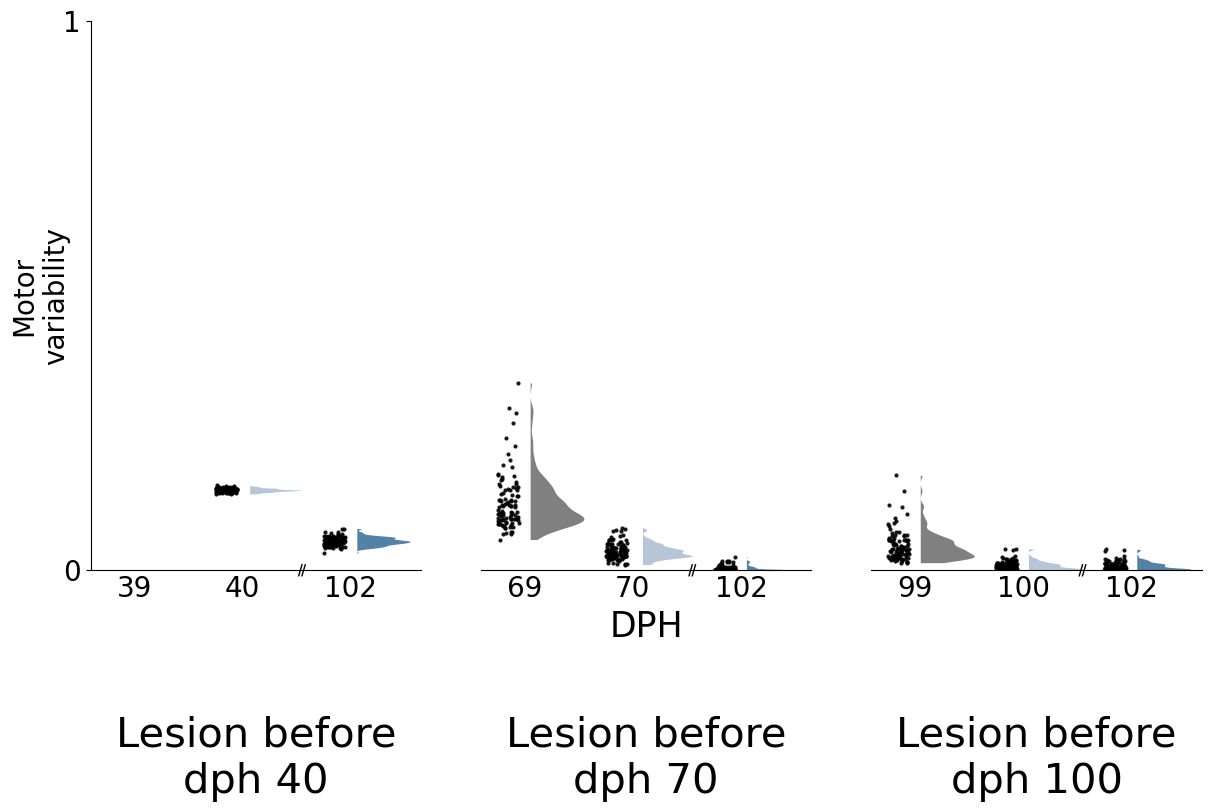

In [127]:
fig = plot_motor_var_violin_conditions(
    data = data_motor_var,
    lesion_day_list=lesion_day_list,
    wanted_days=wanted_days,
    conditions=conditions,
    plot_colors=plot_colors,
    figsize=(12, 8),
    print_stats=True,
)

save_figure("Figure_7c_v2", save=save_figs)

C:\Users\rsankar\AppData\Local\Temp\ipykernel_7196\3677156679.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\rsankar\AppData\Local\Temp\ipykernel_7196\3677156679.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\rsankar\AppData\Local\Temp\ipykernel_7196\3677156679.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(



Stats for lesion at day 0 (RA):
Median for Before Lesion: nan [nan - nan]
Median for After Lesion: 0.4155 [0.3371 - 0.5025]
Median for Terminal Performance: 0.2631 [0.2057 - 0.3311]

Stats for lesion at day 30 (RA):
Median for Before Lesion: 0.1119 [0.0913 - 0.1464]
Median for After Lesion: 0.4399 [0.3574 - 0.4923]
Median for Terminal Performance: 0.2897 [0.2293 - 0.3602]

Stats for lesion at day 60 (RA):
Median for Before Lesion: 0.0384 [0.0259 - 0.0546]
Median for After Lesion: 0.5290 [0.4622 - 0.5682]
Median for Terminal Performance: 0.4022 [0.3509 - 0.4581]


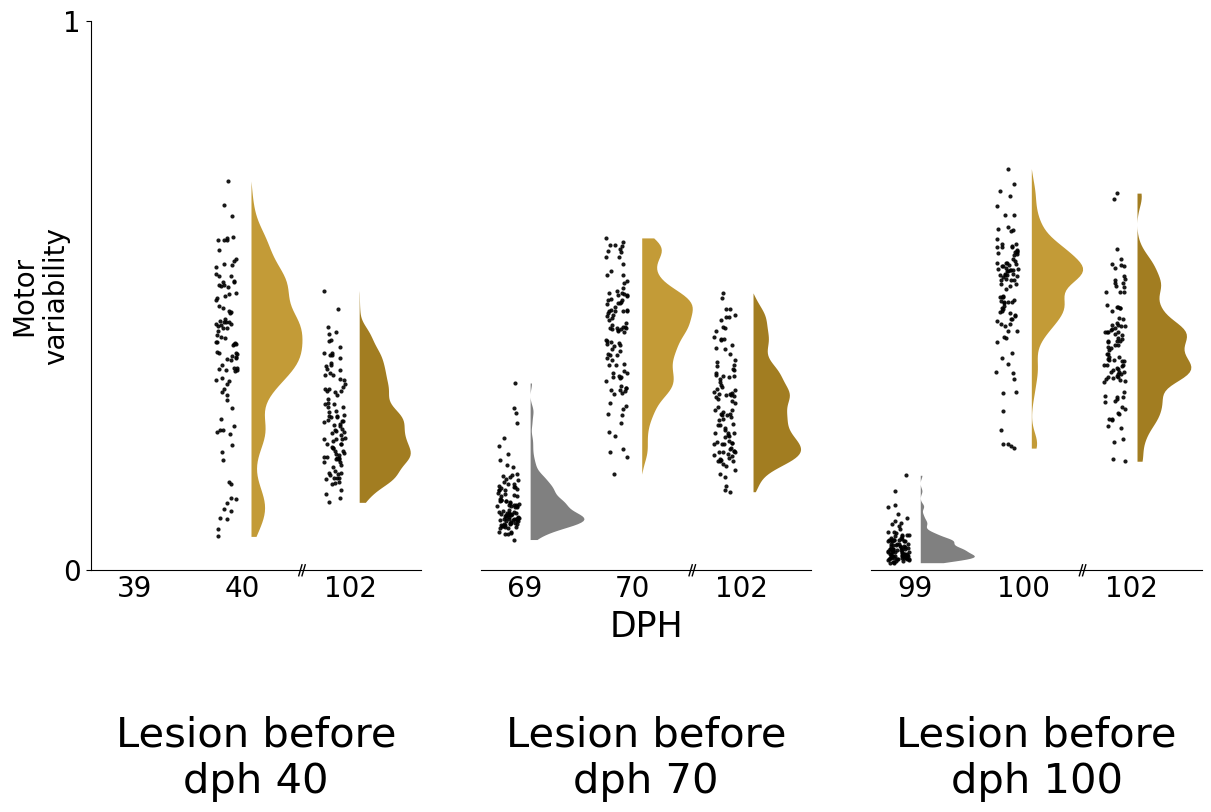

In [128]:
fig = plot_motor_var_violin_conditions(
    data = data_motor_var_ra,
    lesion_day_list=lesion_day_list,
    wanted_days=wanted_days,
    conditions=conditions,
    plot_colors=plot_colors,
    figsize=(12, 8),
    lesion="RA",
    print_stats=True,
)

save_figure("Figure_7f_v2", save=save_figs)

### B.

In [129]:
HERE = Path.cwd()          # notebook directory
# results_dir = HERE / "../Lesion_exp/results"
LESION_CONFIG = HERE / "../Lesion_exp/lesion_params.yaml"

with open(LESION_CONFIG, "r") as f:
    lesion_cfg = yaml.safe_load(f)

print(f"Lesion parameters loaded from {LESION_CONFIG}")


Lesion parameters loaded from c:\Users\rsankar\Desktop\DualPathwayFigures\Repo20Feb2026\Dual_Pathway_RL_songbird\Figures\..\Lesion_exp\lesion_params.yaml


In [ ]:
NOS_SEEDS = 1
time_per_iter = 5.5
state = 1158
np.random.seed(state)
seeds = np.random.randint(0, 100000, NOS_SEEDS)
seeds.sort()

# TIME ESTIMATE
total_iterations = sum(len(param_info["values"]) for param_info in lesion_cfg.values()) * NOS_SEEDS
total_time_hours = (total_iterations * time_per_iter) / 3600
print(f"Estimated total time for robustness analysis: {total_time_hours:.2f} hours")

outputs_all = {}
for param_name, param_info in lesion_cfg.items():
    section = param_info["section"]
    values = param_info["values"]
    
    print(f"\nRunning robustness for {section}.{param_name}")

    terminal_performance = np.zeros((NOS_SEEDS, len(values), 3))
    outputs_all[param_name] = []
    for val_idx, val in enumerate(values):
        val = float(val)  # ensure val is a float for YAML serialization
        if val not in wanted_days:
            print(f" -- Skipping {section}.{param_name} = {val} (not in desired_days)")
            continue
        print(f" -- {param_name} = {val}")

        parameters = update_params(
            params_base,
            **{
                f"{section}.{param_name}": val,
                "params.N_SYLL": 1,
                "params.DAYS": 62, # for quick testing
            }
        )

        if parameters["params"]["N_SYLL"] != 1:
            raise ValueError("N_SYLL must be 1 for robustness analysis.")
        for seed_idx, seed in enumerate(seeds):
            outputs = build_and_run(seed, parameters, NN, output_reward = True, output_action= True)
            outputs_all[param_name].append(outputs)


In [131]:
result_dict = {}
for param_name in outputs_all:
    result_dict[param_name] = {
        "rewards": [outputs['rewards'] for outputs in outputs_all[param_name]],
        "actions": [outputs['actions'] for outputs in outputs_all[param_name]],
    }


In [132]:
# def plot_rewards_and_actions(rewards, actions, wanted_days, DAYS_TOTAL, TRIALS_TOTAL, smoothing=5, figsize=None):
#     # Define colors for the points
#     # convert rewards and actions into np arrays
#     rewards = np.array(rewards)
#     actions = np.array(actions)
#     if param_name == "BG_INTACT_DAYS":
#         point_colors = {'Before': 'grey', 'After': 'lightsteelblue', 'End': 'steelblue'}
#     if param_name == "RA_INTACT_DAYS":
#         point_colors = {'Before': 'grey', 'After': 'goldenrod', 'End': 'darkgoldenrod'}
        
#     offset = 0
#     rewards = rewards.squeeze()  # (params, days, trials)
#     actions = actions.squeeze()  # (params, days, trials, 2)

#     if figsize is None:
#         figsize = (4 * len(wanted_days), 4)

#     fig, axs = plt.subplots(3, len(wanted_days), figsize=figsize, sharey='row')
#     if len(wanted_days) == 1:
#         axs = np.expand_dims(axs, axis=1)

#     for i, lesion_day in enumerate(wanted_days):
#         param_idx = np.where(np.array(wanted_days) == lesion_day)[0][0]
#         # print(f"Lesion at day {lesion_day}")

#         # Flatten data
#         reward_data = rewards[param_idx].reshape(-1)
#         action_data = actions[param_idx].reshape(-1, 2)
#         time_axis = np.linspace(0, DAYS_TOTAL, DAYS_TOTAL * TRIALS_TOTAL)
#         # Stats
#         reward_before_lesion = reward_data[(lesion_day)*TRIALS_TOTAL-100:(lesion_day)*TRIALS_TOTAL]
#         reward_after_lesion = reward_data[(lesion_day)*TRIALS_TOTAL:(lesion_day)*TRIALS_TOTAL+100]
#         reward_terminal = reward_data[-TRIALS_TOTAL:]
#         # print(f"Reward before lesion: {reward_before_lesion.mean():.3f}+-{reward_before_lesion.std():.3f}")
#         # print(f"Reward after lesion: {reward_after_lesion.mean():.3f}+-{reward_after_lesion.std():.3f}")
#         # night jump 
#         # night_jump_before = actions[param_idx][lesion_day-3:lesion_day,0] - actions[param_idx][lesion_day-4:lesion_day-1,-1]
#         # print(f"Night jump: {night_jump_before.mean():.3f}+-{night_jump_before.std():.3f}")
#         night_jump_after = actions[param_idx][lesion_day+1:lesion_day+4,0] - actions[param_idx][lesion_day:lesion_day+3,-1]
#         # print(f"Night jump after: {night_jump_after.mean():.3f}+-{night_jump_after.std():.3f}")
#         # Smooth data
#         smooth_reward = running_mean(reward_data, smoothing)
#         smooth_x = running_mean(action_data[:, 0], smoothing)
#         smooth_y = running_mean(action_data[:, 1], smoothing)
#         # print(f"Actions shape: {actions[param_idx].shape}")
#         mean_motor_var = np.mean(np.std(actions[param_idx], axis = 1),axis=1)
#         # print(f"Mean motor var shape: {mean_motor_var.shape}")
#         smooth_time = time_axis[:len(smooth_reward)] # making sure time axis matches smoothed data length

#         # Plot full trajectories in black
#         axs[0, i].plot(smooth_time + offset, smooth_reward, color='black', lw=1)
#         axs[1, i].plot(smooth_time + offset, smooth_reward, color='black', lw=1)
#         axs[0, i].axvline(lesion_day + offset, linestyle='--', color='grey', alpha=0.5)  # type: ignore
#         axs[1, i].axvline(lesion_day + offset, linestyle='--', color='grey', alpha=0.5)  # type: ignore
#         spacing_with_zoom = 50
#         spacing_without_zoom = 500
#         # scatter points of interest
#         # Row 1: zoomed in around lesion day
#         axs[0, i].scatter(smooth_time[lesion_day*TRIALS_TOTAL - spacing_with_zoom] + offset, reward_before_lesion.mean(), color=point_colors['Before'], s=100, zorder=5)
#         axs[0, i].scatter(smooth_time[lesion_day*TRIALS_TOTAL + spacing_with_zoom] + offset, reward_after_lesion.mean(), color=point_colors['After'], s=100, zorder=5)
#         axs[0, i].scatter(DAYS_TOTAL+ offset, reward_terminal.mean(), color=point_colors['End'], s=100, zorder=5)
#         # Row 2: full trajectory
#         axs[1, i].scatter(smooth_time[lesion_day*TRIALS_TOTAL - spacing_without_zoom] + offset, reward_before_lesion.mean(), color=point_colors['Before'], s=100, zorder=5)
#         axs[1, i].scatter(smooth_time[lesion_day*TRIALS_TOTAL + spacing_without_zoom] + offset, reward_after_lesion.mean(), color=point_colors['After'], s=100, zorder=5)
#         axs[1, i].scatter(DAYS_TOTAL+ offset, reward_terminal.mean(), color=point_colors['End'], s=100, zorder=5)

#         # Formatting
#         axs[0, i].set_xlim(offset+lesion_day - 2, offset+lesion_day + 2)
#         axs[0, i].set_ylim(0, 1)
#         axs[0, i].set_yticks([0, 1])
#         axs[0, i].tick_params(labelsize=10)
#         axs[0, i].spines[['right', 'top']].set_visible(False)

#         axs[1, i].axhline(0, linestyle='--', color='black', alpha=0.1)
#         axs[1, i].set_ylim(0, 1)
#         axs[1, i].set_yticks([0, 1], [0, 1])
#         axs[1, i].tick_params(labelsize=10)
#         axs[1, i].set_xticks(offset + np.arange(0, DAYS_TOTAL + 1, 20))
#         axs[1, i].spines[['right', 'top']].set_visible(False)

#         if i == 0:
#             axs[0, i].set_ylabel("Performance\nMetric", fontsize=11)
#             axs[1, i].set_ylabel("Performance\nMetric", fontsize=12)

#         # Motor variability 
#         # print(f"Actions shape: {actions[param_idx].shape}")
#         motor_var = np.std(actions[param_idx], axis=1)  # (days, 2) variability across trials
#         # print(motor_var.shape)
#         # print(f"Motor Var {motor_var[lesion_day-1]}, {motor_var[lesion_day]}")
#         mean_motor_var = np.mean(motor_var, axis=1)  # (days)
#         # print(f"Motor var lesion from {mean_motor_var[lesion_day-1]:.3f} to {mean_motor_var[lesion_day]:.3f}")
#         axs[2, i].plot(np.arange(1, DAYS_TOTAL + 1) + offset, mean_motor_var, color='black')
#         axs[2, i].axvline(lesion_day + offset, linestyle='--', color='grey', alpha=0.5)  # type: ignore
#         axs[2, i].scatter(lesion_day - 1 + offset, mean_motor_var[lesion_day - 1], color=point_colors['Before'], s=100, zorder=5)
#         axs[2, i].scatter(lesion_day + offset, mean_motor_var[lesion_day], color=point_colors['After'], s=100, zorder=5)
#         axs[2, i].scatter(DAYS_TOTAL-1 + offset, mean_motor_var[DAYS_TOTAL-1], color=point_colors['End'], s=100, zorder=5)
#         # axs[2, i].set_xlim(offset+lesion_day - 2, offset+lesion_day + 2)
#         axs[2, i].set_ylim(0, 1)
#         axs[2, i].set_yticks([0, 1])
#         axs[2, i].set_xticks(offset + np.arange(0, DAYS_TOTAL + 1, 20))
#         axs[2, i].set_xlabel(lesion_day + offset, fontsize=12)
#         axs[2, i].tick_params(labelsize=10)
#         axs[2, i].spines[['right', 'top']].set_visible(False)
#         if i == 0:
#             axs[2, i].set_ylabel("Motor variability", fontsize=12)

#     handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=col, markersize=8, label=lbl)   # type: ignore
#                for lbl, col in point_colors.items()] # type: ignore

#     plt.tight_layout(rect=[0, 0, 0.95, 1])  #type: ignore
#     # plt.show()
#     return fig


In [133]:
def plot_rewards_and_actions(rewards, actions, wanted_days, DAYS_TOTAL, TRIALS_TOTAL,
                             smoothing=5, smoothing_middle=None, figsize=None):
    rewards = np.array(rewards)
    actions = np.array(actions)
    if param_name == "BG_INTACT_DAYS":
        point_colors = {'Before': 'grey', 'After': 'lightsteelblue', 'End': 'steelblue'}
    if param_name == "RA_INTACT_DAYS":
        point_colors = {'Before': 'grey', 'After': 'goldenrod', 'End': 'darkgoldenrod'}

    if smoothing_middle is None:
        smoothing_middle = smoothing

    offset = 0
    rewards = rewards.squeeze()
    actions = actions.squeeze()

    if figsize is None:
        figsize = (4 * len(wanted_days), 4)

    fig, axs = plt.subplots(3, len(wanted_days), figsize=figsize, sharey='row')
    if len(wanted_days) == 1:
        axs = np.expand_dims(axs, axis=1)

    # 3 dph ticks used for rows 1 and 2
    tick_pos = [0, 30, 60]

    for i, lesion_day in enumerate(wanted_days):
        param_idx = np.where(np.array(wanted_days) == lesion_day)[0][0]
        dph_label = f"Lesion before dph {int(lesion_day + 40)}"

        reward_data = rewards[param_idx].reshape(-1)
        action_data = actions[param_idx].reshape(-1, 2)
        time_axis = np.linspace(0, DAYS_TOTAL, DAYS_TOTAL * TRIALS_TOTAL)

        reward_before_lesion = reward_data[(lesion_day)*TRIALS_TOTAL-100:(lesion_day)*TRIALS_TOTAL]
        reward_after_lesion  = reward_data[(lesion_day)*TRIALS_TOTAL:(lesion_day)*TRIALS_TOTAL+100]
        reward_terminal      = reward_data[-TRIALS_TOTAL:]

        night_jump_after = actions[param_idx][lesion_day+1:lesion_day+4,0] - actions[param_idx][lesion_day:lesion_day+3,-1]

        smooth_reward_top = running_mean(reward_data, smoothing)
        smooth_reward_mid = running_mean(reward_data, smoothing_middle)
        smooth_time_top   = time_axis[:len(smooth_reward_top)]
        smooth_time_mid   = time_axis[:len(smooth_reward_mid)]

        mean_motor_var = np.mean(np.std(actions[param_idx], axis=1), axis=1)

        spacing_with_zoom    = 50
        spacing_without_zoom = 500

        # Row 0 — zoomed around lesion day
        axs[0, i].plot(smooth_time_top + offset, smooth_reward_top, color='black', lw=1)
        axs[0, i].axvline(lesion_day + offset, linestyle='--', color='grey', alpha=0.5)
        axs[0, i].scatter(smooth_time_top[lesion_day*TRIALS_TOTAL - spacing_with_zoom] + offset, reward_before_lesion.mean(), color=point_colors['Before'], s=100, zorder=5)
        axs[0, i].scatter(smooth_time_top[lesion_day*TRIALS_TOTAL + spacing_with_zoom] + offset, reward_after_lesion.mean(),  color=point_colors['After'],  s=100, zorder=5)
        axs[0, i].scatter(DAYS_TOTAL + offset, reward_terminal.mean(), color=point_colors['End'], s=100, zorder=5)
        axs[0, i].set_xlim(offset + lesion_day - 2, offset + lesion_day + 2)
        axs[0, i].set_ylim(0, 1)
        axs[0, i].set_yticks([0, 1])
        zoom_ticks = [lesion_day - 2, lesion_day, lesion_day + 2]
        axs[0, i].set_xticks([offset + t for t in zoom_ticks])
        axs[0, i].set_xticklabels([str(t + 40) for t in zoom_ticks], fontsize=20)
        axs[0, i].tick_params(axis='x', labelsize=20)
        axs[0, i].tick_params(axis='y', labelsize=20)
        # axs[0, i].set_xlabel(dph_label, fontsize=20)
        axs[0, i].spines[['right', 'top', 'left']].set_visible(False)

        # Row 1 — full trajectory (more smoothing)
        axs[1, i].plot(smooth_time_mid + offset, smooth_reward_mid, color='black', lw=1)
        axs[1, i].axvline(lesion_day + offset, linestyle='--', color='grey', alpha=0.5)
        axs[1, i].axhline(0, linestyle='--', color='black', alpha=0.1)
        axs[1, i].scatter(smooth_time_mid[lesion_day*TRIALS_TOTAL - spacing_without_zoom] + offset, reward_before_lesion.mean(), color=point_colors['Before'], s=100, zorder=5)
        axs[1, i].scatter(smooth_time_mid[lesion_day*TRIALS_TOTAL + spacing_without_zoom] + offset, reward_after_lesion.mean(),  color=point_colors['After'],  s=100, zorder=5)
        axs[1, i].scatter(DAYS_TOTAL + offset, reward_terminal.mean(), color=point_colors['End'], s=100, zorder=5)
        axs[1, i].set_ylim(0, 1)
        axs[1, i].set_yticks([0, 1], [0, 1])
        axs[1, i].set_xticks([offset + t for t in tick_pos])
        axs[1, i].set_xticklabels([str(t + 40) for t in tick_pos], fontsize=20)
        axs[1, i].tick_params(axis='x', labelsize=20)
        axs[1, i].tick_params(axis='y', labelsize=20)
        # axs[1, i].set_xlabel(dph_label, fontsize=20)
        axs[1, i].spines[['right', 'top', 'left']].set_visible(False)

        if i == 0:
            axs[0, i].set_ylabel("Performance\nmetric", fontsize=20)
            axs[1, i].set_ylabel("Performance\nmetric", fontsize=20)
            axs[0, i].spines[['left']].set_visible(True)
            axs[1, i].spines[['left']].set_visible(True)

        # Row 2 — motor variability
        motor_var      = np.std(actions[param_idx], axis=1)
        mean_motor_var = np.mean(motor_var, axis=1)
        axs[2, i].plot(np.arange(1, DAYS_TOTAL + 1) + offset, mean_motor_var, color='black')
        axs[2, i].axvline(lesion_day + offset, linestyle='--', color='grey', alpha=0.5)
        axs[2, i].scatter(lesion_day - 1 + offset, mean_motor_var[lesion_day - 1], color=point_colors['Before'], s=100, zorder=5)
        axs[2, i].scatter(lesion_day     + offset, mean_motor_var[lesion_day],     color=point_colors['After'],  s=100, zorder=5)
        axs[2, i].scatter(DAYS_TOTAL - 1 + offset, mean_motor_var[DAYS_TOTAL - 1], color=point_colors['End'],   s=100, zorder=5)
        axs[2, i].set_ylim(0, 1)
        axs[2, i].set_yticks([0, 1])
        axs[2, i].set_xticks([offset + t for t in tick_pos])
        axs[2, i].set_xticklabels([str(t + 40) for t in tick_pos], fontsize=20)
        axs[2, i].tick_params(axis='x', labelsize=20)
        axs[2, i].tick_params(axis='y', labelsize=20)
        # axs[2, i].set_xlabel(dph_label, fontsize=20)
        axs[2, i].spines[['right', 'top', 'left']].set_visible(False)
        if i == 0:
            axs[2, i].set_ylabel("Motor\nvariability", fontsize=20)
            axs[2, i].spines[['left']].set_visible(True)

    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=col, markersize=5, label=lbl)
               for lbl, col in point_colors.items()]

    plt.tight_layout()
    return fig


C:\Users\rsankar\AppData\Local\Temp\ipykernel_7196\3493929502.py:54: RuntimeWarning: Mean of empty slice.
  axs[0, i].scatter(smooth_time_top[lesion_day*TRIALS_TOTAL - spacing_with_zoom] + offset, reward_before_lesion.mean(), color=point_colors['Before'], s=100, zorder=5)
c:\ProgramData\anaconda3\envs\dual_pathway_env\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\rsankar\AppData\Local\Temp\ipykernel_7196\3493929502.py:72: RuntimeWarning: Mean of empty slice.
  axs[1, i].scatter(smooth_time_mid[lesion_day*TRIALS_TOTAL - spacing_without_zoom] + offset, reward_before_lesion.mean(), color=point_colors['Before'], s=100, zorder=5)
c:\ProgramData\anaconda3\envs\dual_pathway_env\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\rsankar\AppData\Local\Temp\ipykernel_7196\3854169436.py:85: Fu

Figure saved as  Plots\Figure_7_mosaic.png


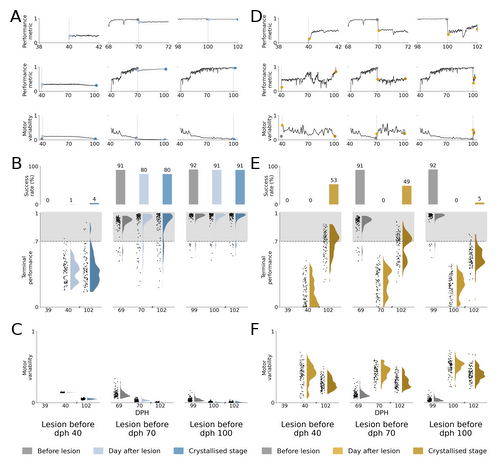

In [135]:
import io
from matplotlib.patches import Patch

def fig_to_rgb_array(fig, dpi=150):
    """Render a matplotlib figure to a float32 (H, W, 3) array in [0, 1]."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight', facecolor='white')
    buf.seek(0)
    arr = plt.imread(buf)
    return arr[..., :3]

DAYS  = 62
TRIALS = params_base["params"]["TRIALS"]

BE_FIGHEIGHT = 8
CF_FIGHEIGHT = BE_FIGHEIGHT * (10 / 14)

# ── A  BG trajectories ────────────────────────────────────────────────────
param_name = "BG_INTACT_DAYS"
fig_a = plot_rewards_and_actions(
    result_dict['BG_INTACT_DAYS']['rewards'],
    result_dict['BG_INTACT_DAYS']['actions'],
    wanted_days, DAYS, TRIALS, smoothing=50, smoothing_middle=300,
)
fig_a.set_size_inches(12, BE_FIGHEIGHT)

# ── B  BG terminal-performance violins ───────────────────────────────────
fig_b = plot_results_violin_conditions(
    data=data, lesion_day_list=lesion_day_list, wanted_days=wanted_days,
    conditions=conditions, plot_colors=plot_colors, success_threshold=0.7,
    figsize=(12, BE_FIGHEIGHT), lesion="BG",
)

# ── C  BG motor-variability violins ──────────────────────────────────────
fig_c = plot_motor_var_violin_conditions(
    data=data_motor_var, lesion_day_list=lesion_day_list, wanted_days=wanted_days,
    conditions=conditions, plot_colors=plot_colors, figsize=(12, CF_FIGHEIGHT), lesion="BG",
)

# ── D  RA trajectories ────────────────────────────────────────────────────
param_name = "RA_INTACT_DAYS"
fig_d = plot_rewards_and_actions(
    result_dict['RA_INTACT_DAYS']['rewards'],
    result_dict['RA_INTACT_DAYS']['actions'],
    wanted_days, DAYS, TRIALS, smoothing=50, smoothing_middle=300,
)
fig_d.set_size_inches(12, BE_FIGHEIGHT)

# ── E  RA terminal-performance violins ───────────────────────────────────
fig_e = plot_results_violin_conditions(
    data=data_ra, lesion_day_list=lesion_day_list, wanted_days=wanted_days,
    conditions=conditions, plot_colors=plot_colors, success_threshold=0.7,
    figsize=(12, BE_FIGHEIGHT), lesion="RA",
)

# ── F  RA motor-variability violins ──────────────────────────────────────
fig_f = plot_motor_var_violin_conditions(
    data=data_motor_var_ra, lesion_day_list=lesion_day_list, wanted_days=wanted_days,
    conditions=conditions, plot_colors=plot_colors, figsize=(12, CF_FIGHEIGHT), lesion="RA",
)

# ── Legend figures ────────────────────────────────────────────────────────
legend_elements_bg = [
    Patch(facecolor='grey',           alpha=0.75, label='Before lesion'),
    Patch(facecolor='lightsteelblue', alpha=0.75, label='Day after lesion'),
    Patch(facecolor='steelblue',      alpha=0.75, label='Crystallised stage'),
]
fig_leg_bg, ax_leg_bg = plt.subplots(figsize=(12, 0.5))
ax_leg_bg.axis('off')
ax_leg_bg.legend(handles=legend_elements_bg, loc='center', frameon=False,
                 fontsize=25, handlelength=1.5, handleheight=1.2, ncol=3)
plt.tight_layout(pad=0.1)

legend_elements_ra = [
    Patch(facecolor='grey',          alpha=0.75, label='Before lesion'),
    Patch(facecolor='goldenrod',     alpha=0.75, label='Day after lesion'),
    Patch(facecolor='darkgoldenrod', alpha=0.75, label='Crystallised stage'),
]
fig_leg_ra, ax_leg_ra = plt.subplots(figsize=(12, 0.5))
ax_leg_ra.axis('off')
ax_leg_ra.legend(handles=legend_elements_ra, loc='center', frameon=False,
                 fontsize=25, handlelength=1.5, handleheight=1.2, ncol=3)
plt.tight_layout(pad=0.1)

# ── Rasterise all ─────────────────────────────────────────────────────────
imgs_left  = [fig_to_rgb_array(f) for f in [fig_a, fig_b, fig_c]]
imgs_right = [fig_to_rgb_array(f) for f in [fig_d, fig_e, fig_f]]
img_leg_bg = fig_to_rgb_array(fig_leg_bg)
img_leg_ra = fig_to_rgb_array(fig_leg_ra)
for f in [fig_a, fig_b, fig_c, fig_d, fig_e, fig_f, fig_leg_bg, fig_leg_ra]:
    plt.close(f)

# ── Helpers ───────────────────────────────────────────────────────────────
def fit_width(img, target_w):
    h, w = img.shape[:2]
    if w < target_w:
        pad = np.ones((h, target_w - w, 3), dtype=img.dtype)
        return np.concatenate([img, pad], axis=1)
    elif w > target_w:
        trim = (w - target_w) // 2
        return img[:, trim:trim + target_w, :]
    return img

def pad_bottom(img, target_h):
    h, w = img.shape[:2]
    if h >= target_h:
        return img
    pad = np.ones((target_h - h, w, 3), dtype=img.dtype)
    return np.concatenate([img, pad], axis=0)

w_left  = max(im.shape[1] for im in imgs_left)
w_right = max(im.shape[1] for im in imgs_right)
imgs_left  = [fit_width(im, w_left)  for im in imgs_left]
imgs_right = [fit_width(im, w_right) for im in imgs_right]

# ── Add top padding to each panel (~10pt at 150 dpi) ─────────────────────
top_pad_px = 21
def add_top_pad(img, pad_px):
    pad = np.ones((pad_px, img.shape[1], 3), dtype=img.dtype)
    return np.concatenate([pad, img], axis=0)

imgs_left  = [add_top_pad(im, top_pad_px) for im in imgs_left]
imgs_right = [add_top_pad(im, top_pad_px) for im in imgs_right]

# ── Stack panels with vertical gaps between rows ──────────────────────────
row_gap_px    = 80   # space between A/B, B/C (and D/E, E/F)
legend_gap_px = 30  # extra space between C/F and legend row

def interleave_gaps(imgs, gap_px):
    out = []
    for k, img in enumerate(imgs):
        out.append(img)
        if k < len(imgs) - 1:
            out.append(np.ones((gap_px, img.shape[1], 3), dtype=img.dtype))
    return np.vstack(out)

col_left_content  = interleave_gaps(imgs_left,  row_gap_px)
col_right_content = interleave_gaps(imgs_right, row_gap_px)

img_leg_bg = fit_width(img_leg_bg, w_left)
img_leg_ra = fit_width(img_leg_ra, w_right)
leg_h = max(img_leg_bg.shape[0], img_leg_ra.shape[0])
img_leg_bg = pad_bottom(img_leg_bg, leg_h)
img_leg_ra = pad_bottom(img_leg_ra, leg_h)

# Gap before legend
gap_leg_left  = np.ones((legend_gap_px, w_left,  3), dtype=img_leg_bg.dtype)
gap_leg_right = np.ones((legend_gap_px, w_right, 3), dtype=img_leg_ra.dtype)

col_left  = np.vstack([col_left_content,  gap_leg_left,  img_leg_bg])
col_right = np.vstack([col_right_content, gap_leg_right, img_leg_ra])

max_h = max(col_left.shape[0], col_right.shape[0])
col_left  = pad_bottom(col_left,  max_h)
col_right = pad_bottom(col_right, max_h)

# ── Margins for panel labels ───────────────────────────────────────────────
col_margin = 80
margin_l = np.ones((max_h, col_margin, 3), dtype=col_left.dtype)
margin_m = np.ones((max_h, col_margin, 3), dtype=col_left.dtype)

mosaic = np.hstack([margin_l, col_left, margin_m, col_right])

# ── Display ───────────────────────────────────────────────────────────────
fig_mosaic, ax = plt.subplots(figsize=(5.2, 14))
ax.imshow(mosaic, interpolation='lanczos')
ax.axis('off')

# Labels sit inside the top_pad white strip above each panel's content
label_pos = []
y = 0
for k, (img, lbl) in enumerate(zip(imgs_left, ['A', 'B', 'C'])):
    label_pos.append((0, y - 20, lbl))
    y += img.shape[0]
    if k < len(imgs_left) - 1:
        y += row_gap_px

y = 0
for k, (img, lbl) in enumerate(zip(imgs_right, ['D', 'E', 'F'])):
    label_pos.append((col_margin + w_left, y - 20, lbl))
    y += img.shape[0]
    if k < len(imgs_right) - 1:
        y += row_gap_px

for (xp, yp, lbl) in label_pos:
    ax.text(xp, yp, lbl, fontsize=12, fontweight='normal', color='black',
            va='top', ha='left', transform=ax.transData)

plt.tight_layout(pad=0, rect=[0.08, 0, 1, 1])

save_figure("Figure_7_mosaic", save=True, dpi=600, format='png')
plt.show()
